# Hypothesis 1: What drives taxi trip volume across NYC zones?

This analysis explores how weather conditions and POI density influence taxi demand using a zone × date dataset.

In [152]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

YEAR_COLORS = {2019: "#2F5597", 2020: "#C0504D", 2025: "#548235"}
PHASE_LABELS = {2019: "Pre-COVID baseline", 2020: "COVID disruption", 2025: "Post-COVID comparison"}

dfs = []
for year in [2019, 2020, 2025]:
    _df = pd.read_parquet(f"data/processed/final/zone_date_master_{year}.parquet")
    _df["year"] = year
    dfs.append(_df)

df = pd.concat(dfs, ignore_index=True)
df["date"] = pd.to_datetime(df["date"]).dt.date

print(f"Total rows: {len(df):,}")
print(f"Years: {sorted(df['year'].unique())}")
df.head()

Total rows: 257,069
Years: [np.int64(2019), np.int64(2020), np.int64(2025)]


,date,taxi_zone_id,fare_amount_yellow,total_amount_yellow,trip_distance_yellow,trips_pickup_yellow,trips_pickup_street_hail,poi_count_total,poi_name_examples,poi_count_commercial,...,prcp,awnd,snow,temp_avg,rainy_day,heavy_rain_day,pleasant_temp_day,windy_day,season,year
0,2019-01-01,1,80.240952,91.850952,6.109048,21,21,NaN,NaN,NaN,...,1.5,NaN,0.0,9.15,1,0,0,NaN,winter,2019
1,2019-01-01,3,45.306000,48.960000,8.690000,5,5,46.0,ALLERTON PLAYGROUND; AMBER COURT OF PELHAM GAR...,2.0,...,1.5,NaN,0.0,9.15,1,0,0,NaN,winter,2019
2,2019-01-01,4,13.344622,16.317612,3.421168,582,582,130.0,10 STREET PEDESTRIAN; 11 BC SERENITY GARDEN; 5...,0.0,...,1.5,NaN,0.0,9.15,1,0,0,NaN,winter,2019
3,2019-01-01,6,3.000000,27.320000,0.300000,1,1,68.0,AMERICAN LEGION POST 1544; ANGELS CIRCLE 9 / 1...,2.0,...,1.5,NaN,0.0,9.15,1,0,0,NaN,winter,2019
4,2019-01-01,7,11.466474,13.665281,2.916589,604,604,100.0,114 PRECINCT; 49 ST OVER I-278 BQE WEST LEG; A...,4.0,...,1.5,NaN,0.0,9.15,1,0,0,NaN,winter,2019


### Data Granularity

The dataset is structured at a zone × date level, where each row represents aggregated taxi demand for a specific taxi zone on a given day.

## Data Sanity Check

We verify that key variables (weather features) do not contain missing values.

In [153]:
weather_cols = ["temp_avg", "rainy_day", "heavy_rain_day", "pleasant_temp_day", "windy_day", "awnd", "prcp", "snow"]
df[weather_cols].isna().sum()

temp_avg                 0
rainy_day                0
heavy_rain_day           0
pleasant_temp_day        0
windy_day            24777
awnd                 24777
prcp                     0
snow                     0
dtype: int64

**Note:** `awnd` (wind speed) shows 24,777 missing values. This is expected — NOAA did not provide wind data for January–March 2019. Wind analysis in this notebook uses 2025 only.

## Weather Analysis

We examine how weather conditions drive yellow taxi demand across NYC zones, using all 3 years (2019, 2020, 2025).

The analysis has two stages:
- **Initial**: rain and temperature (the primary hypothesis variables)
- **Deeper**: wind, snow, precipitation intensity, temperature bins, zone sensitivity, and regression

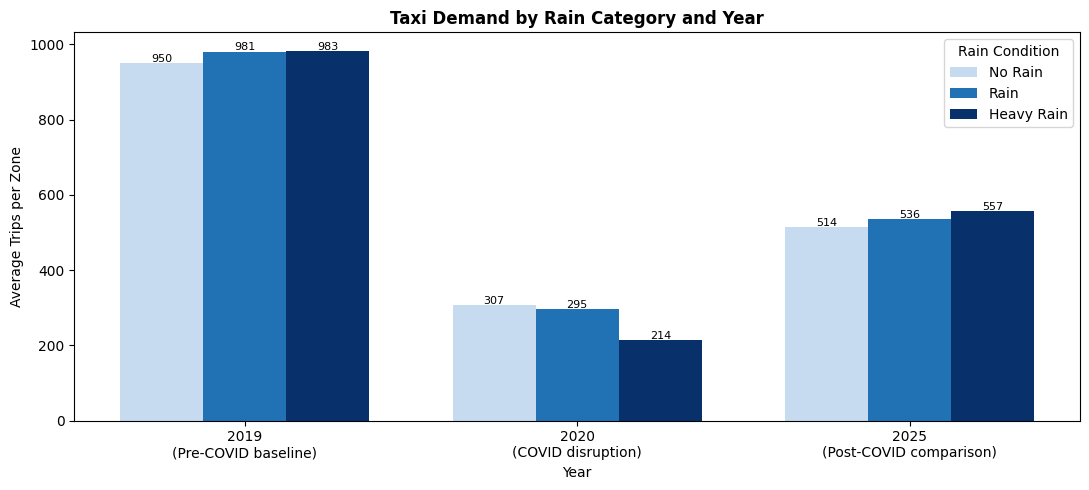

In [154]:
df["rain_category"] = "No Rain"
df.loc[df["rainy_day"] == 1, "rain_category"] = "Rain"
df.loc[df["heavy_rain_day"] == 1, "rain_category"] = "Heavy Rain"

category_order = ["No Rain", "Rain", "Heavy Rain"]
category_colors = ["#c6dbef", "#2171b5", "#08306b"]

rain_by_year = (
    df.groupby(["year", "rain_category"])["trips_pickup_yellow"]
    .mean()
    .reset_index()
)

years = [2019, 2020, 2025]
x = np.arange(len(years))
width = 0.25

fig, ax = plt.subplots(figsize=(11, 5))

for i, (cat, color) in enumerate(zip(category_order, category_colors)):
    vals = [
        rain_by_year.loc[(rain_by_year["year"] == y) & (rain_by_year["rain_category"] == cat), "trips_pickup_yellow"].values[0]
        for y in years
    ]
    bars = ax.bar(x + (i - 1) * width, vals, width=width, color=color, label=cat)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, v + 3, f"{v:.0f}", ha="center", fontsize=8)

ax.set_title("Taxi Demand by Rain Category and Year", fontweight="bold")
ax.set_ylabel("Average Trips per Zone")
ax.set_xlabel("Year")
ax.set_xticks(x)
ax.set_xticklabels([f"{y}\n({PHASE_LABELS[y]})" for y in years])
ax.legend(title="Rain Condition")
plt.tight_layout()
plt.show()

### Rain Effect by Year

Rain days are split into 3 mutually exclusive categories: No Rain, Rain (light to moderate), and Heavy Rain. We compare average trips per zone across all 3 years.

### Results: Rain Effect on Taxi Demand by Year

| Year | No Rain | Rain | Heavy Rain | Rain Lift | Heavy Rain Lift |
|---|---|---|---|---|---|
| 2019 (Pre-COVID) | 950 | 981 | 983 | +3.3% | +3.5% |
| 2020 (COVID) | 307 | 295 | 214 | **-3.9%** | **-30.3%** |
| 2025 (Post-COVID) | 514 | 536 | 557 | +4.3% | +8.4% |

### Key Findings

- **Rain has a modest but consistent lift in normal years:** In 2019 and 2025, rain and heavy rain increase taxi demand by 3–8%
- **2020 reversed the pattern:** During COVID, rain suppressed already-low demand rather than boosting it; people simply stayed home regardless of weather.
- **Heavy rain sensitivity grew post-COVID:** The heavy rain lift more than doubled from +3.5% in 2019 to +8.4% in 2025.
- **COVID collapse is visible across all conditions:** 2020 demand is roughly 1/3 of 2019 regardless of rain category.

### Temperature Effect

A linear correlation test between temperature and taxi demand. Non-linear effects are explored further via temperature bins in Section 3.

In [155]:
# Pearson correlation between average temperature and zone-level trip count
corr = df["trips_pickup_yellow"].corr(df["temp_avg"])
print(f"Correlation between temp_avg and trips_pickup_yellow: {corr:.4f}")

Correlation between temp_avg and trips_pickup_yellow: -0.0521


A correlation of -0.052 confirms that temperature has no meaningful linear relationship with taxi demand. Temperature bins in Section 3 explore whether non-linear effects exist.

## Summary of Initial Weather Analysis

Rain modestly increases taxi demand. Heavy rain amplifies this further. Temperature shows negligible correlation with demand.

The following sections go deeper: wind, snow, precipitation intensity, temperature non-linearity, combined weather conditions, and zone-level sensitivity.

## Deeper Weather Analysis

### 1. Wind & Snow

Wind and snow are available in the weather data but were not used in the initial analysis.
Wind speed data for 2025 is complete; note that NOAA did not provide wind data for Jan–Mar 2019, so wind analysis uses 2025 only.

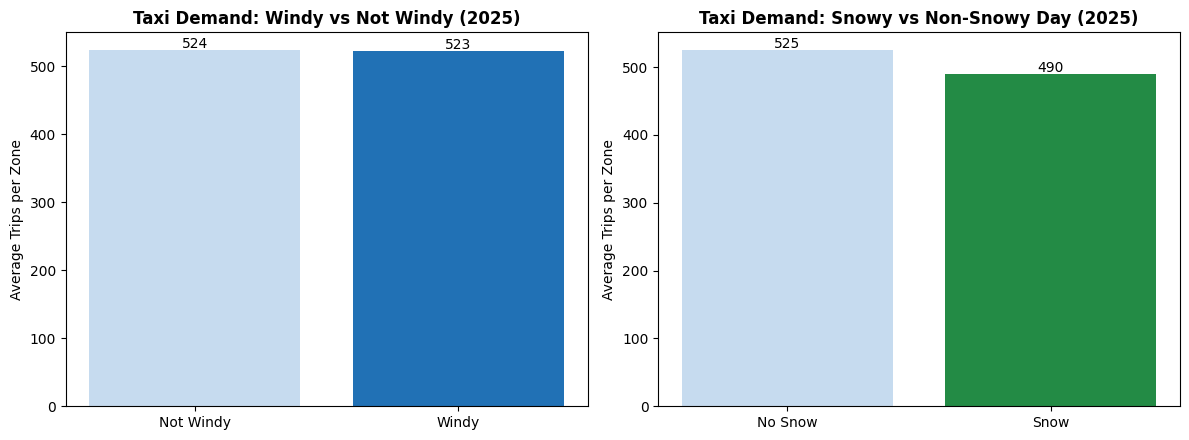

Wind lift: -0.2%
Snow lift: -6.6%


In [156]:
# Wind data uses 2025 only — NOAA did not provide awnd for Jan–Mar 2019 (NaN in those months)
df_2025 = df[df["year"] == 2025].copy()

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# --- Wind ---
wind_effect = df_2025.groupby("windy_day")["trips_pickup_yellow"].mean()
ax = axes[0]
bars = ax.bar(["Not Windy", "Windy"], wind_effect.values, color=["#c6dbef", "#2171b5"])
ax.set_title("Taxi Demand: Windy vs Not Windy (2025)", fontweight="bold")
ax.set_ylabel("Average Trips per Zone")
for bar, v in zip(bars, wind_effect.values):
    ax.text(bar.get_x() + bar.get_width() / 2, v + 3, f"{v:.0f}", ha="center")

# --- Snow ---
# snowy_day = 1 if any measurable snow recorded (snow > 0mm)
df_2025["snowy_day"] = (df_2025["snow"].fillna(0) > 0).astype(int)
snow_effect = df_2025.groupby("snowy_day")["trips_pickup_yellow"].mean()
ax = axes[1]
bars = ax.bar(["No Snow", "Snow"], snow_effect.values, color=["#c6dbef", "#238b45"])
ax.set_title("Taxi Demand: Snowy vs Non-Snowy Day (2025)", fontweight="bold")
ax.set_ylabel("Average Trips per Zone")
for bar, v in zip(bars, snow_effect.values):
    ax.text(bar.get_x() + bar.get_width() / 2, v + 3, f"{v:.0f}", ha="center")

plt.tight_layout()
plt.show()

print(f"Wind lift: {(wind_effect[1] / wind_effect[0] - 1) * 100:.1f}%")
print(f"Snow lift: {(snow_effect[1] / snow_effect[0] - 1) * 100:.1f}%")

### Results: Wind & Snow Effect (2025)

| Condition | No Weather | Weather | Lift |
|---|---|---|---|
| Wind | 524 | 523 | -0.2% |
| Snow | 525 | 490 | -6.6% |

### Key Findings

- **Wind has no effect:** A -0.2% lift is negligible; wind does not meaningfully change taxi demand.
- **Snow reduces demand:** Unlike rain, snow days see fewer trips (-6.6%). People tend to stay home or cancel plans rather than substitute to taxis.

### 2. Precipitation Intensity

Binary rain flags (rainy / not rainy) collapse all rainfall into one bucket.
Binning raw precipitation into ordered ranges tests whether demand scales continuously with intensity.

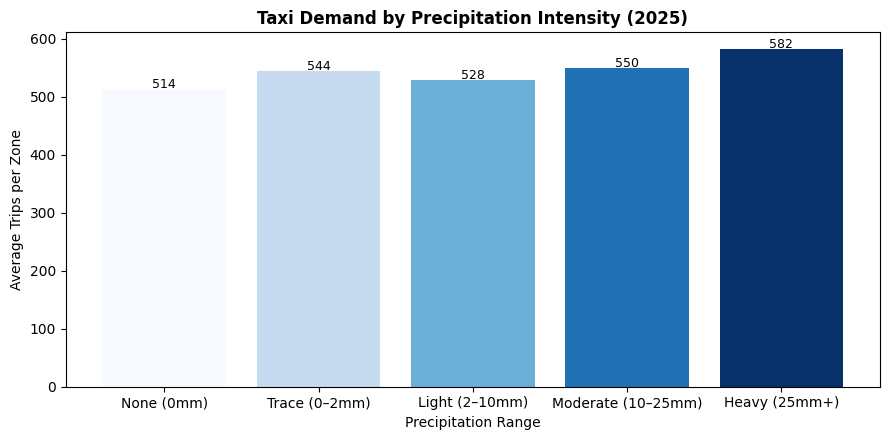

In [157]:
# Binary rain flags flatten the signal — this bins raw precipitation (mm) into 5 ordered ranges
# to test whether demand scales continuously with rain intensity
df_2025 = df[df["year"] == 2025].copy()
df_2025["prcp_bin"] = pd.cut(
    df_2025["prcp"].fillna(0),
    bins=[-0.1, 0, 2, 10, 25, 999],
    labels=["None (0mm)", "Trace (0–2mm)", "Light (2–10mm)", "Moderate (10–25mm)", "Heavy (25mm+)"]
)

prcp_effect = df_2025.groupby("prcp_bin", observed=True)["trips_pickup_yellow"].mean()

fig, ax = plt.subplots(figsize=(9, 4.5))
colors = ["#f7fbff", "#c6dbef", "#6baed6", "#2171b5", "#08306b"]
bars = ax.bar(prcp_effect.index.astype(str), prcp_effect.values, color=colors)
ax.set_title("Taxi Demand by Precipitation Intensity (2025)", fontweight="bold")
ax.set_xlabel("Precipitation Range")
ax.set_ylabel("Average Trips per Zone")
for bar, v in zip(bars, prcp_effect.values):
    ax.text(bar.get_x() + bar.get_width() / 2, v + 2, f"{v:.0f}", ha="center", fontsize=9)
plt.tight_layout()
plt.show()

### Results: Taxi Demand by Precipitation Intensity (2025)

| Precipitation | Avg Trips per Zone |
|---|---|
| None (0mm) | 514 |
| Trace (0–2mm) | 544 |
| Light (2–10mm) | 528 |
| Moderate (10–25mm) | 550 |
| Heavy (25mm+) | 582 |

### Key Findings

- **Demand scales with rain intensity:** Trips increase from no rain (514) to heavy rain (582), a 13% lift at the heaviest bucket.
- **Trace rain already lifts demand:** Even a small amount of rain (0–2mm) pushes demand up, suggesting passengers switch to taxis quickly.
- **Light rain dips slightly (528):** The small drop vs trace rain is just noise; the overall pattern is clear: more rain, more trips.
- **Heavy rain is the strongest driver:** At 25mm+, demand peaks at 582, the highest across all intensity levels.

### 3. Temperature: Non-Linear Effects

The linear correlation between temperature and demand was near zero (-0.05). We bin `temp_avg` into 7 ranges to check whether demand changes meaningfully at cold or hot extremes.

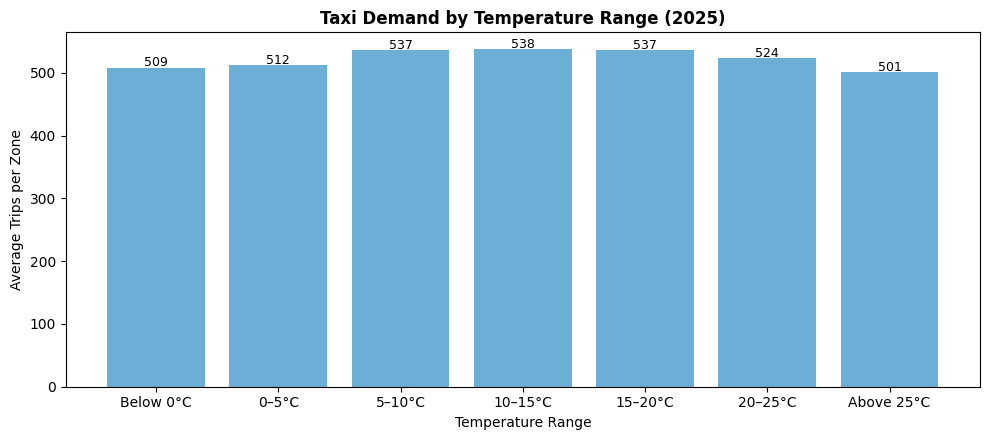

In [158]:
# A near-zero linear correlation doesn't rule out non-linear effects
# Binning temp_avg into 7 ranges reveals whether demand changes at cold or hot extremes
df_2025 = df[df["year"] == 2025].copy()
df_2025["temp_bin"] = pd.cut(
    df_2025["temp_avg"],
    bins=[-20, 0, 5, 10, 15, 20, 25, 40],
    labels=["Below 0°C", "0–5°C", "5–10°C", "10–15°C", "15–20°C", "20–25°C", "Above 25°C"]
)

temp_bin_effect = df_2025.groupby("temp_bin", observed=True)["trips_pickup_yellow"].mean()

fig, ax = plt.subplots(figsize=(10, 4.5))
bars = ax.bar(temp_bin_effect.index.astype(str), temp_bin_effect.values, color="#6baed6")
ax.set_title("Taxi Demand by Temperature Range (2025)", fontweight="bold")
ax.set_xlabel("Temperature Range")
ax.set_ylabel("Average Trips per Zone")
for bar, v in zip(bars, temp_bin_effect.values):
    ax.text(bar.get_x() + bar.get_width() / 2, v + 2, f"{v:.0f}", ha="center", fontsize=9)
plt.tight_layout()
plt.show()

### Results: Taxi Demand by Temperature Range (2025)

| Temperature | Avg Trips per Zone |
|---|---|
| Below 0°C | 509 |
| 0–5°C | 512 |
| 5–10°C | 537 |
| 10–15°C | 538 |
| 15–20°C | 537 |
| 20–25°C | 524 |
| Above 25°C | 501 |

### Key Findings

- **Temperature has minimal impact on demand:** The range across all bins is just 509–538, roughly a 5% spread. No temperature range causes a meaningful spike or drop.
- **Consistent with the linear correlation:** The near-zero Pearson coefficient (-0.05) holds up even with binning; there is no hidden non-linear effect worth acting on.
- **Conclusion:** Temperature is not a driver of taxi demand. Weather effects are explained by rain, not temperature.

### 4. Combined Weather Conditions: Rain + Wind

We split days into 4 mutually exclusive groups to test whether rain and wind compound each other's effect on demand.

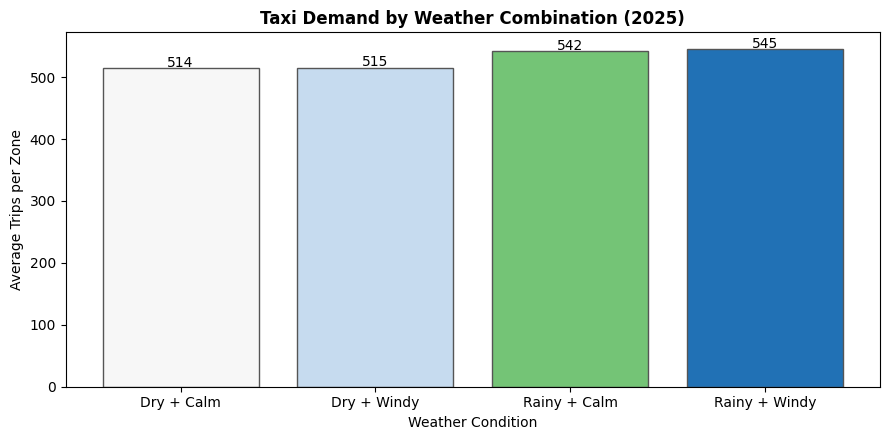

In [159]:
# Split days into 4 mutually exclusive groups: rain × wind
# Tests whether the two conditions interact (i.e. rain+wind > rain alone + wind alone)
df_2025 = df[df["year"] == 2025].dropna(subset=["windy_day", "rainy_day"]).copy()
df_2025["weather_combo"] = df_2025.apply(
    lambda r: ("Rainy" if r["rainy_day"] else "Dry") + " + " + ("Windy" if r["windy_day"] else "Calm"),
    axis=1
)

combo_order = ["Dry + Calm", "Dry + Windy", "Rainy + Calm", "Rainy + Windy"]
combo_effect = df_2025.groupby("weather_combo")["trips_pickup_yellow"].mean().reindex(combo_order)

fig, ax = plt.subplots(figsize=(9, 4.5))
colors = ["#f7f7f7", "#c6dbef", "#74c476", "#2171b5"]
bars = ax.bar(combo_effect.index, combo_effect.values, color=colors, edgecolor="#555")
ax.set_title("Taxi Demand by Weather Combination (2025)", fontweight="bold")
ax.set_ylabel("Average Trips per Zone")
ax.set_xlabel("Weather Condition")
for bar, v in zip(bars, combo_effect.values):
    ax.text(bar.get_x() + bar.get_width() / 2, v + 2, f"{v:.0f}", ha="center")
plt.tight_layout()
plt.show()

### Results: Taxi Demand by Weather Combination (2025)

| Condition | Avg Trips per Zone |
|---|---|
| Dry + Calm | 514 |
| Dry + Windy | 515 |
| Rainy + Calm | 542 |
| Rainy + Windy | 545 |

### Key Findings

- **Rain shows a modest lift (~5.5%):** Demand moves from ~514 on dry days to ~542 on rainy days, present but not dramatic.
- **Wind has no effect:** Dry+Windy (515) is the same as Dry+Calm (514).
- **No compounding:** Rain+Wind (545) and Rain alone (542) are nearly identical; the two conditions do not amplify each other.

### 5. Zone-Level Weather Sensitivity

Not all zones respond to rain equally. We compute a per-zone rain lift to identify which zones gain the most and which lose, and check whether zone type (residential vs park vs transit hub) explains the difference.

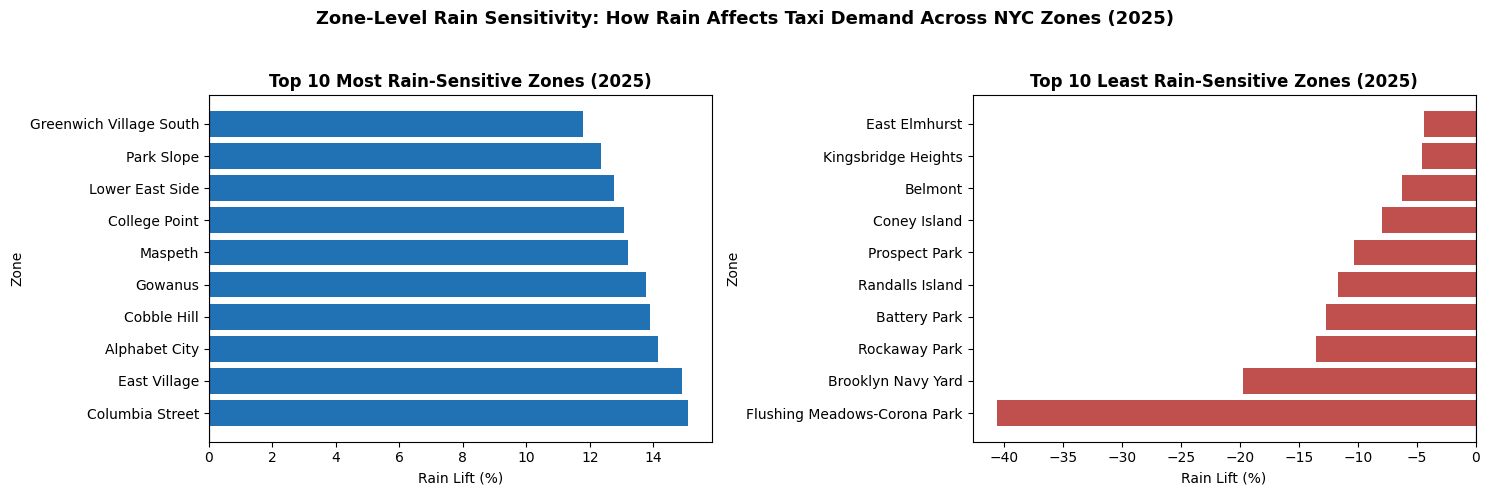

Median rain lift across zones: 3.6%
Zones with positive rain lift:  165 / 218


In [160]:
import geopandas as gpd

zones_gdf = gpd.read_file("data/raw/taxi_zones/taxi_zones.shp")
zone_name_map = zones_gdf.set_index("LocationID")["zone"].to_dict()

df_2025 = df[df["year"] == 2025].copy()

zone_rain = (
    df_2025.groupby(["taxi_zone_id", "rainy_day"])["trips_pickup_yellow"]
    .mean()
    .unstack("rainy_day")
)
zone_rain.columns = ["non_rainy_avg", "rainy_avg"]
zone_rain = zone_rain.dropna()
zone_rain = zone_rain[zone_rain["non_rainy_avg"] > 5]
zone_rain["rain_lift_pct"] = (zone_rain["rainy_avg"] / zone_rain["non_rainy_avg"] - 1) * 100
zone_rain = zone_rain.reset_index()
zone_rain["zone_name"] = zone_rain["taxi_zone_id"].map(zone_name_map).fillna(zone_rain["taxi_zone_id"].astype(str))

top10 = zone_rain.nlargest(10, "rain_lift_pct")
bot10 = zone_rain.nsmallest(10, "rain_lift_pct")

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].barh(top10["zone_name"], top10["rain_lift_pct"], color="#2171b5")
axes[0].set_title("Top 10 Most Rain-Sensitive Zones (2025)", fontweight="bold")
axes[0].set_xlabel("Rain Lift (%)")
axes[0].set_ylabel("Zone")
axes[0].axvline(0, color="black", linewidth=0.8)

axes[1].barh(bot10["zone_name"], bot10["rain_lift_pct"], color="#c0504d")
axes[1].set_title("Top 10 Least Rain-Sensitive Zones (2025)", fontweight="bold")
axes[1].set_xlabel("Rain Lift (%)")
axes[1].set_ylabel("Zone")
axes[1].axvline(0, color="black", linewidth=0.8)

fig.suptitle("Zone-Level Rain Sensitivity: How Rain Affects Taxi Demand Across NYC Zones (2025)", fontsize=13, fontweight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

print(f"Median rain lift across zones: {zone_rain['rain_lift_pct'].median():.1f}%")
print(f"Zones with positive rain lift:  {(zone_rain['rain_lift_pct'] > 0).sum()} / {len(zone_rain)}")

### Results: Zone-Level Rain Sensitivity (2025)

| Metric | Value |
|---|---|
| Median rain lift across zones | +3.6% |
| Zones with positive rain lift | 165 / 218 (76%) |
| Highest rain lift (Columbia Street) | ~+15% |
| Lowest rain lift (Flushing Meadows-Corona Park) | ~-40% |

### Key Findings

- **Dense residential and walkable neighborhoods gain the most on rainy days:** Columbia Street, East Village, Alphabet City, Cobble Hill, and Gowanus all see 12–15% lifts; residents switch from walking to taxis when it rains.
- **Parks and outdoor zones lose demand on rainy days:** Flushing Meadows-Corona Park, Prospect Park, Coney Island, and Rockaway Park all see sharp drops(-40%); rain cancels the outdoor activity that was generating taxi trips in the first place.
- **Zone character explains rain sensitivity more than any other factor:** Walkable urban neighborhoods gain, outdoor/recreational zones lose.
- **City-level averages mask this variation:** The modest city-wide rain lift (~4–5%) hides a wide spread across individual zones.

## Comprehensive Weather Analysis Summary

### Key Findings

- **Rain is the only consistent weather driver:** Demand rises modestly on rainy days (3–8%) and scales with intensity; heavy rain produces the strongest lift.
- **Snow suppresses demand:** Unlike rain, snow days see fewer trips (-6.6%); people cancel plans rather than switch to taxis.
- **Wind and temperature don't matter:** Both show negligible effects across all analyses.
- **The most important finding is at the zone level:** Rain's effect is not uniform. Walkable urban neighborhoods (East Village, Alphabet City, Cobble Hill) gain on rainy days as residents switch from walking. Parks and outdoor zones (Flushing Meadows-Corona Park, Prospect Park, Coney Island, Rockaway Park) lose demand because rain cancels the activity that drew trips in the first place.

### Conclusion

Rain has a modest, directional effect on taxi demand at the city level. But the real story is at the zone level: whether rain helps or hurts depends entirely on what the zone is. A walkable neighborhood and an outdoor recreational area respond to the same rainstorm in completely opposite ways.

## City-Level Analysis (Temporal Trends)

We aggregate total taxi trips per day to analyze demand patterns over time.

In [161]:
city_df = df.groupby("date")["trips_pickup_yellow"].sum().reset_index()
city_df.head()

,date,trips_pickup_yellow
0,2019-01-01,185880
1,2019-01-02,194739
2,2019-01-03,219512
3,2019-01-04,231281
4,2019-01-05,232382


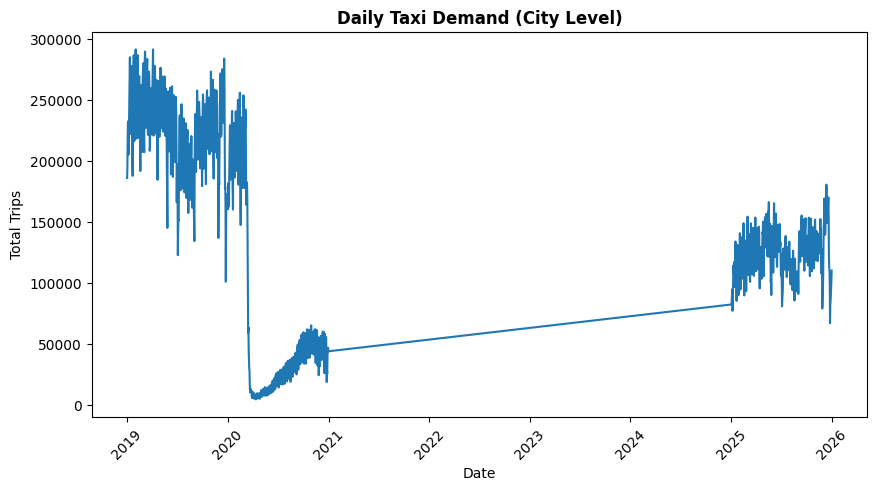

In [162]:
plt.figure(figsize=(10,5))
plt.plot(city_df["date"], city_df["trips_pickup_yellow"])
plt.xticks(rotation=45)
plt.title("Daily Taxi Demand (City Level)", fontweight="bold")
plt.ylabel("Total Trips")
plt.xlabel("Date")
plt.show()

## Summary of City-Level Analysis

To understand overall demand dynamics, taxi trips are aggregated at the city level on a daily basis.

The time-series plot shows significant day-to-day variability in total taxi demand, with no clear long-term upward or downward trend over the year. However, recurring fluctuations suggest the presence of cyclical patterns, likely driven by weekly behavioral trends such as weekday–weekend differences.

### Key Insights

- Taxi demand varies significantly across days.
- No strong long-term trend is observed over the year.
- Repeating fluctuations suggest underlying temporal cycles.

### Interpretation

The observed variability indicates that taxi demand is influenced by dynamic temporal factors beyond weather conditions. These may include weekly commuting patterns, social behavior, and special events. 

### Conclusion

City-level demand patterns highlight the importance of temporal dynamics, suggesting that short-term behavioral cycles play a key role in influencing taxi usage.

## Spatial Analysis : POI Density vs Taxi Demand

We analyze how taxi demand varies across zones based on POI density.

In [163]:
zone_df = df.groupby("taxi_zone_id").agg({
    "trips_pickup_yellow": "mean",
    "poi_count_total": "first"
}).reset_index()

In [164]:
zone_df[["trips_pickup_yellow", "poi_count_total"]].corr()

,trips_pickup_yellow,poi_count_total
trips_pickup_yellow,1.000000,0.020861
poi_count_total,0.020861,1.000000


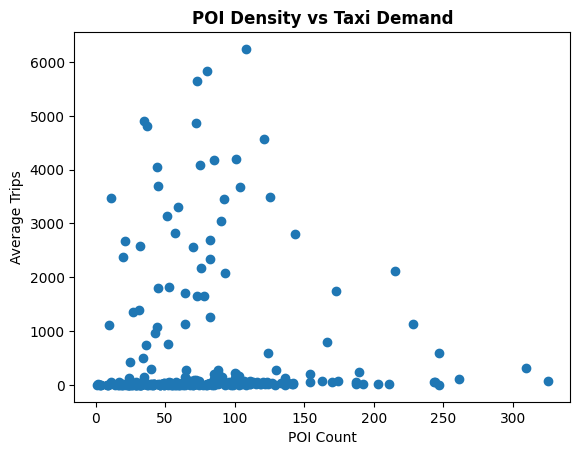

In [165]:
plt.scatter(zone_df["poi_count_total"], zone_df["trips_pickup_yellow"])
plt.xlabel("POI Count")
plt.ylabel("Average Trips")
plt.title("POI Density vs Taxi Demand", fontweight="bold")
plt.show()

## Summary of Spatial Analysis

To understand how spatial characteristics influence taxi demand, we analyze the relationship between POI (Points of Interest) density and average taxi trips across zones.

The scatter plot of POI count versus average taxi trips shows a highly dispersed pattern with no clear linear relationship. While a few zones exhibit very high taxi demand, these are limited in number and do not correspond consistently to the highest POI counts.

Most zones cluster at low to moderate POI counts with relatively low taxi demand, suggesting that simply having more POIs does not necessarily translate into higher taxi usage. Additionally, there are instances where zones with high POI counts exhibit low demand and vice versa, indicating the presence of other influencing factors.

### Key Insights

- POI density alone shows a weak relationship with taxi demand.
- A small number of zones account for disproportionately high demand, likely corresponding to key urban or transit hubs.
- The variability in demand across zones suggests that location context and type of POIs may be more important than total POI count.

### Interpretation

These findings suggest that aggregated POI counts may mask important heterogeneity across different types of locations. Not all POIs contribute equally to taxi demand, and factors such as zone importance, accessibility, and temporal dynamics likely play a more significant role.

### Conclusion

While POI density provides a spatial perspective on taxi demand, it is not a strong standalone predictor. A more granular analysis incorporating POI categories or contextual location features may yield deeper insights into demand patterns.

## Overall Findings

This analysis combines spatial and temporal perspectives to understand taxi demand across NYC zones.

- Weather, particularly rainfall, is the strongest driver of taxi demand.
- Temperature has negligible influence on demand.
- POI density shows a weak and inconsistent relationship with demand.
- Demand exhibits strong temporal variability, indicating the presence of additional behavioral patterns.

## Final Conclusion

Taxi demand is driven more by short-term temporal factors, especially weather conditions and behavioral cycles, than by static spatial features such as POI density. This suggests that dynamic context plays a more critical role in shaping urban mobility patterns.